<a href="https://colab.research.google.com/github/teejiayi99-droid/KQC-7016-Assignment-1/blob/main/assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Assignment 1: Exploratory Data Analytics
# Theme: Smart City
# Topic: Urban Air Quality Monitoring using Sensor Data
# Dataset: AirQualityUCI.csv

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from google.colab import drive

# Plot style
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Load Dataset

CSV_FILE = "/content/drive/MyDrive/Colab Notebooks/AirQualityUCI.csv"

# Your uploaded CSV uses comma separator
df = pd.read_csv(CSV_FILE)

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully.
Original shape: (9357, 15)

First 5 rows of the dataset:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888



Column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [ ]:
# 2. Initial Data Understanding

print("\nDataset information:")
df.info()

print("\nMissing values before cleaning:")
print(df.isnull().sum())

print("\nDuplicated rows before cleaning:")
print(df.duplicated().sum())

print("\nSummary statistics before cleaning:")
display(df.describe())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB

Missing values before cleaning:
Date             0
Time     

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [ ]:
# 3. Clean Column Names and Remove Empty Rows/Columns

# Clean column names
df.columns = df.columns.str.strip()

# Drop fully empty columns
df = df.dropna(axis=1, how='all')

# Drop fully empty rows
df = df.dropna(axis=0, how='all')

print("Shape after removing fully empty rows/columns:", df.shape)

print("\nCleaned column names:")
print(df.columns.tolist())

Shape after removing fully empty rows/columns: (9357, 15)

Cleaned column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [ ]:
# 4. Replace Invalid Sensor Values

# In AirQualityUCI, -200 represents missing/invalid sensor readings
df = df.replace(-200, np.nan)

print("Missing values after replacing -200 with NaN:")
print(df.isnull().sum())

Missing values after replacing -200 with NaN:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [ ]:
# 5. Convert Date and Time into Datetime

df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    errors='coerce'
)

# Remove rows where Datetime cannot be created
df = df.dropna(subset=['Datetime'])

# Sort by time
df = df.sort_values('Datetime').reset_index(drop=True)

print("Datetime conversion completed.")
print("\nFirst 5 rows after datetime conversion:")
display(df[['Date', 'Time', 'Datetime']].head())

print("\nShape after datetime cleaning:", df.shape)

Datetime conversion completed.

First 5 rows after datetime conversion:


,Date,Time,Datetime
0,3/10/2004,18:00:00,2004-03-10 18:00:00
1,3/10/2004,19:00:00,2004-03-10 19:00:00
2,3/10/2004,20:00:00,2004-03-10 20:00:00
3,3/10/2004,21:00:00,2004-03-10 21:00:00
4,3/10/2004,22:00:00,2004-03-10 22:00:00



Shape after datetime cleaning: (9357, 16)


In [ ]:
# 6. Select Relevant Variables for Analysis

selected_cols = [
    'Datetime',
    'CO(GT)',
    'C6H6(GT)',
    'NOx(GT)',
    'NO2(GT)',
    'T',
    'RH',
    'AH'
]

# Keep only columns that exist
selected_cols = [col for col in selected_cols if col in df.columns]

df = df[selected_cols].copy()

print("Selected columns for analysis:")
print(df.columns.tolist())

print("\nFirst 5 rows after selecting relevant columns:")
display(df.head())

print("\nMissing values before handling:")
print(df.isnull().sum())

Selected columns for analysis:
['Datetime', 'CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']

First 5 rows after selecting relevant columns:


,Datetime,CO(GT),C6H6(GT),NOx(GT),NO2(GT),T,RH,AH
0,2004-03-10 18:00:00,2.6,11.9,166.0,113.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,9.4,103.0,92.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,9.0,131.0,114.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,9.2,172.0,122.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,6.5,131.0,116.0,11.2,59.6,0.7888



Missing values before handling:
Datetime       0
CO(GT)      1683
C6H6(GT)     366
NOx(GT)     1639
NO2(GT)     1642
T            366
RH           366
AH           366
dtype: int64


In [ ]:
# 7. Handle Missing Values

# Identify numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Interpolate missing values because this is time-series sensor data
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

# Fill remaining missing values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Drop duplicate rows
df = df.drop_duplicates()

print("Data cleaning completed.")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicated rows after cleaning:")
print(df.duplicated().sum())

print("\nShape after cleaning:", df.shape)

print("\nFirst 5 cleaned rows:")
display(df.head())

Data cleaning completed.

Missing values after cleaning:
Datetime    0
CO(GT)      0
C6H6(GT)    0
NOx(GT)     0
NO2(GT)     0
T           0
RH          0
AH          0
dtype: int64

Duplicated rows after cleaning:
0

Shape after cleaning: (9357, 8)

First 5 cleaned rows:


,Datetime,CO(GT),C6H6(GT),NOx(GT),NO2(GT),T,RH,AH
0,2004-03-10 18:00:00,2.6,11.9,166.0,113.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,9.4,103.0,92.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,9.0,131.0,114.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,9.2,172.0,122.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,6.5,131.0,116.0,11.2,59.6,0.7888


In [ ]:
# 8. Feature Engineering

df['Hour'] = df['Datetime'].dt.hour
df['Day'] = df['Datetime'].dt.day
df['Month'] = df['Datetime'].dt.month
df['Weekday'] = df['Datetime'].dt.day_name()

# Create Day/Night category
df['DayNight'] = np.where(
    (df['Hour'] >= 7) & (df['Hour'] <= 18),
    'Daytime',
    'Nighttime'
)

# Create time period category
def assign_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['TimePeriod'] = df['Hour'].apply(assign_period)

print("Feature engineering completed.")

print("\nFirst 5 rows with new features:")
display(df[['Datetime', 'Hour', 'Month', 'Weekday', 'DayNight', 'TimePeriod']].head())

Feature engineering completed.

First 5 rows with new features:


,Datetime,Hour,Month,Weekday,DayNight,TimePeriod
0,2004-03-10 18:00:00,18,3,Wednesday,Daytime,Evening
1,2004-03-10 19:00:00,19,3,Wednesday,Nighttime,Evening
2,2004-03-10 20:00:00,20,3,Wednesday,Nighttime,Evening
3,2004-03-10 21:00:00,21,3,Wednesday,Nighttime,Night
4,2004-03-10 22:00:00,22,3,Wednesday,Nighttime,Night


In [ ]:
# 9. Summary Statistics

print("\nDescriptive statistics:")
display(df.describe())

print("\nDay/Night distribution:")
print(df['DayNight'].value_counts())

print("\nTime period distribution:")
print(df['TimePeriod'].value_counts())

print("\nMonthly record count:")
print(df['Month'].value_counts().sort_index())


Descriptive statistics:


,Datetime,CO(GT),C6H6(GT),NOx(GT),NO2(GT),T,RH,AH,Hour,Day,Month
count,9357,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2004-09-21 16:00:00,2.130603,10.179155,241.922197,109.632094,18.233408,49.191386,1.019621,11.498557,15.876884,6.310356
min,2004-03-10 18:00:00,0.100000,0.100000,2.000000,2.000000,-1.900000,9.200000,0.184700,0.000000,1.000000,1.000000
25%,2004-06-16 05:00:00,1.100000,4.500000,96.000000,76.000000,11.700000,35.800000,0.732300,5.000000,8.000000,3.000000
50%,2004-09-21 16:00:00,1.800000,8.300000,180.000000,104.917526,17.600000,49.600000,0.989500,11.000000,16.000000,6.000000
75%,2004-12-28 03:00:00,2.900000,14.100000,326.000000,136.314685,24.300000,62.300000,1.306700,18.000000,23.000000,9.000000
max,2005-04-04 14:00:00,11.900000,63.700000,1479.000000,340.000000,44.600000,88.700000,2.231000,23.000000,31.000000,12.000000
std,NaN,1.431736,7.503812,204.315075,46.462311,8.781791,17.194506,0.402203,6.923182,8.808653,3.438160



Day/Night distribution:
DayNight
Nighttime    4680
Daytime      4677
Name: count, dtype: int64

Time period distribution:
TimePeriod
Night        3120
Morning      2730
Afternoon    1948
Evening      1559
Name: count, dtype: int64

Monthly record count:
Month
1      744
2      672
3     1254
4      807
5      744
6      720
7      744
8      744
9      720
10     744
11     720
12     744
Name: count, dtype: int64


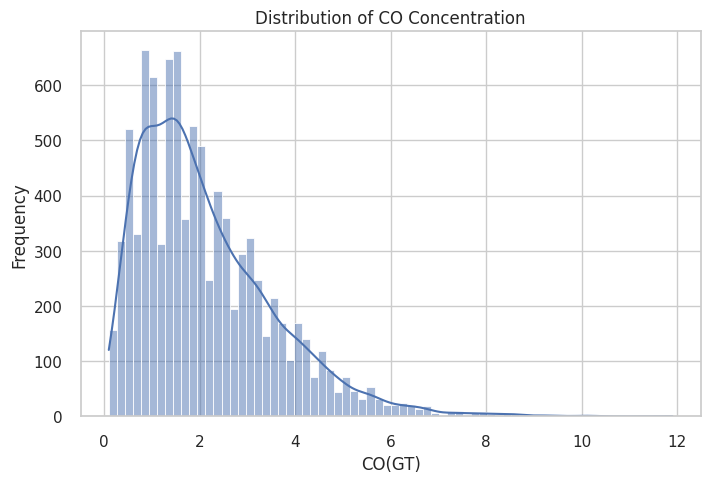

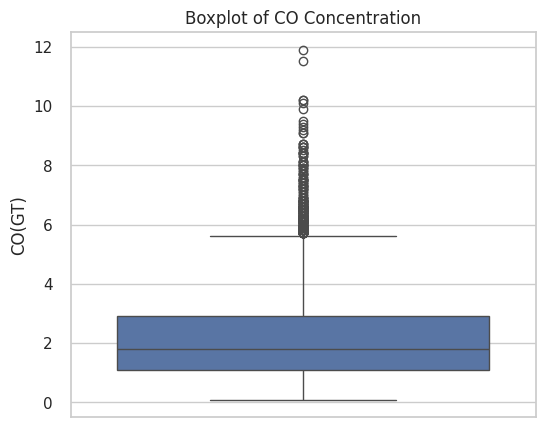

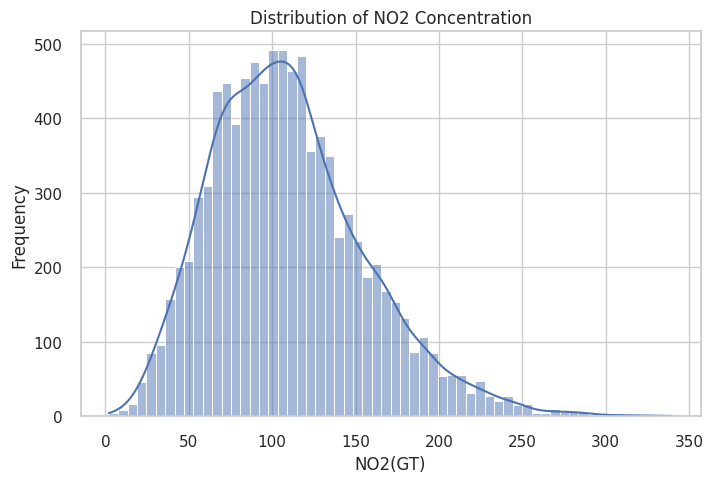

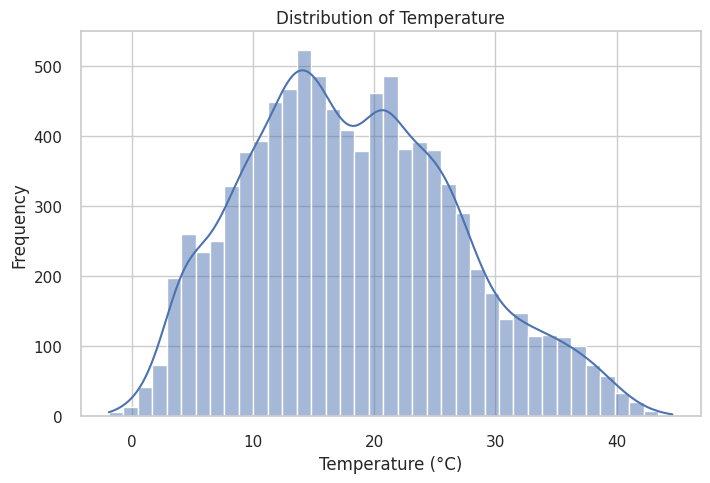

In [ ]:
# 10. EDA: Univariate Analysis

# Histogram of CO concentration
plt.figure(figsize=(8, 5))
sns.histplot(df['CO(GT)'], kde=True)
plt.title('Distribution of CO Concentration')
plt.xlabel('CO(GT)')
plt.ylabel('Frequency')
plt.show()

# Boxplot of CO concentration
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['CO(GT)'])
plt.title('Boxplot of CO Concentration')
plt.ylabel('CO(GT)')
plt.show()

# Histogram of NO2 concentration
plt.figure(figsize=(8, 5))
sns.histplot(df['NO2(GT)'], kde=True)
plt.title('Distribution of NO2 Concentration')
plt.xlabel('NO2(GT)')
plt.ylabel('Frequency')
plt.show()

# Histogram of Temperature
plt.figure(figsize=(8, 5))
sns.histplot(df['T'], kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

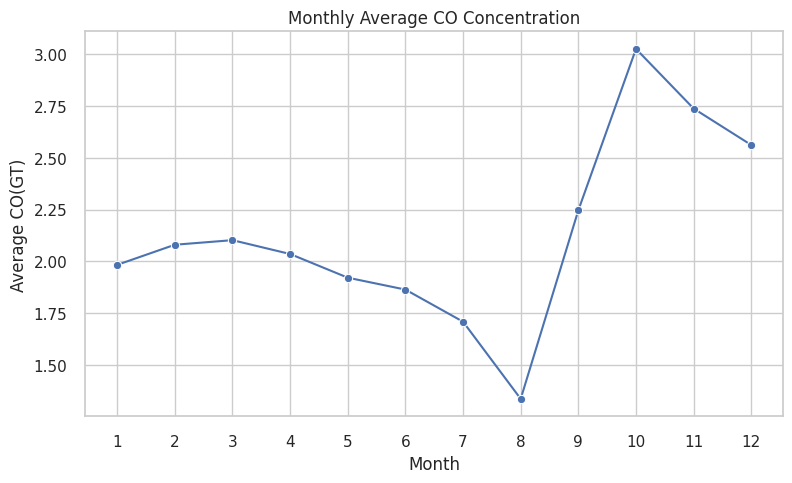

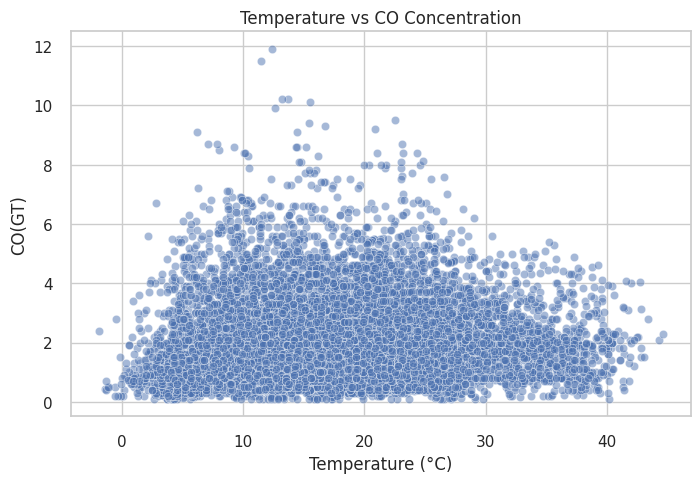

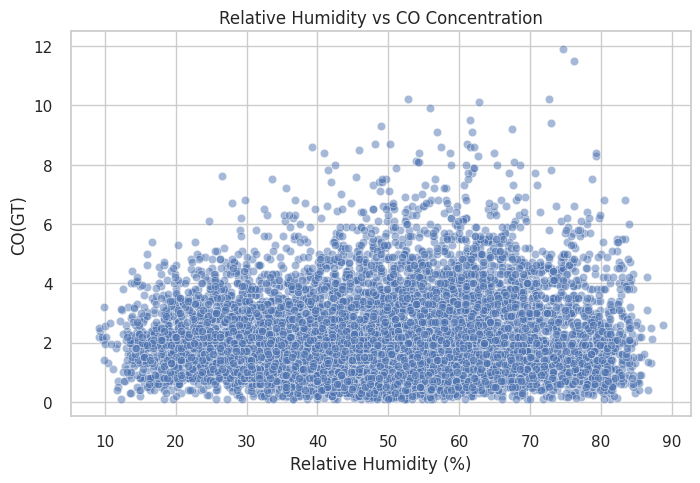

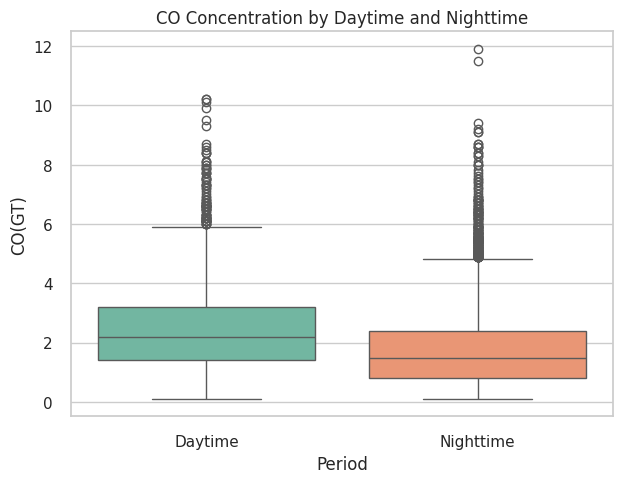

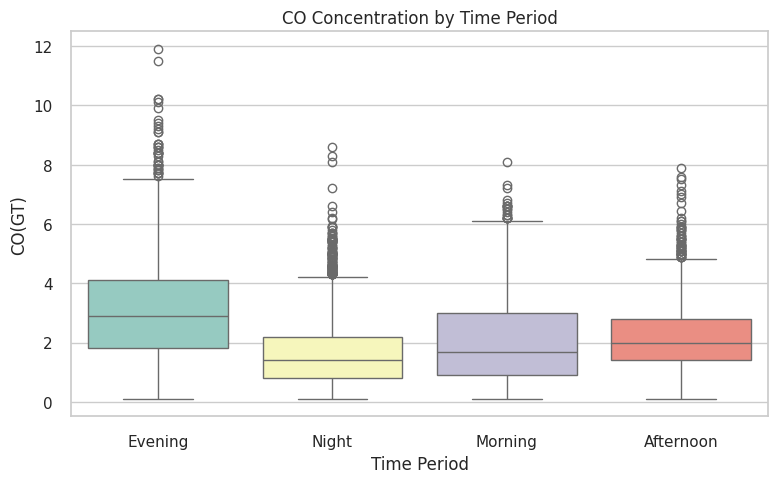

In [ ]:
# 11. EDA: Bivariate Analysis

# 1. Monthly average CO concentration
monthly_co = df.groupby('Month')['CO(GT)'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=monthly_co,
    x='Month',
    y='CO(GT)',
    marker='o'
)

plt.title('Monthly Average CO Concentration')
plt.xlabel('Month')
plt.ylabel('Average CO(GT)')
plt.xticks(range(1, 13))
plt.show()

# Temperature vs CO
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='T', y='CO(GT)', alpha=0.5)
plt.title('Temperature vs CO Concentration')
plt.xlabel('Temperature (°C)')
plt.ylabel('CO(GT)')
plt.show()

# Relative Humidity vs CO
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='RH', y='CO(GT)', alpha=0.5)
plt.title('Relative Humidity vs CO Concentration')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('CO(GT)')
plt.show()

# CO by Day/Night
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='DayNight', y='CO(GT)', hue='DayNight', palette='Set2', legend=False)
plt.title('CO Concentration by Daytime and Nighttime')
plt.xlabel('Period')
plt.ylabel('CO(GT)')
plt.show()

# CO by Time Period
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='TimePeriod', y='CO(GT)', hue='TimePeriod', palette='Set3', legend=False)
plt.title('CO Concentration by Time Period')
plt.xlabel('Time Period')
plt.ylabel('CO(GT)')
plt.show()

Correlation matrix:


,CO(GT),C6H6(GT),NOx(GT),NO2(GT),T,RH,AH
CO(GT),1.000000,0.816518,0.791272,0.675804,0.018899,0.062650,0.060264
C6H6(GT),0.816518,1.000000,0.655009,0.570269,0.190598,-0.063581,0.151764
NOx(GT),0.791272,0.655009,1.000000,0.763038,-0.246280,0.212168,-0.122630
NO2(GT),0.675804,0.570269,0.763038,1.000000,-0.194418,-0.077801,-0.322243
T,0.018899,0.190598,-0.246280,-0.194418,1.000000,-0.574466,0.658761
RH,0.062650,-0.063581,0.212168,-0.077801,-0.574466,1.000000,0.170529
AH,0.060264,0.151764,-0.122630,-0.322243,0.658761,0.170529,1.000000


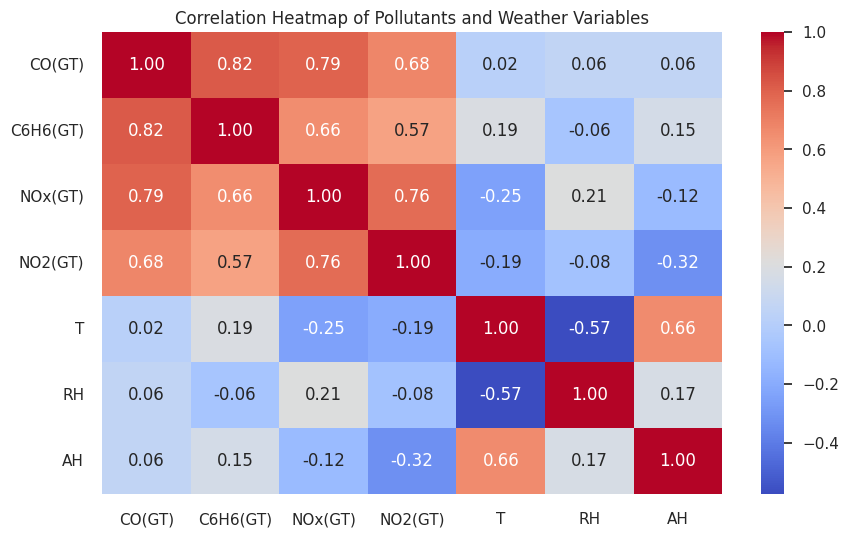

In [ ]:
# 12. EDA: Multivariate Analysis - Correlation Heatmap

corr = df[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']].corr()

print("Correlation matrix:")
display(corr)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Pollutants and Weather Variables')
plt.show()

In [ ]:
# 13. Outlier Detection using Z-score and IQR

# Z-score method
mean_co = df['CO(GT)'].mean()
std_co = df['CO(GT)'].std()

df['CO_z_score'] = (df['CO(GT)'] - mean_co) / std_co

df_anomalies_z = df[np.abs(df['CO_z_score']) > 3]

print("Anomalies detected using Z-score method:", len(df_anomalies_z))
display(df_anomalies_z[['Datetime', 'CO(GT)', 'CO_z_score']].head())

# IQR method
Q1 = df['CO(GT)'].quantile(0.25)
Q3 = df['CO(GT)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_anomalies_iqr = df[
    (df['CO(GT)'] < lower_bound) |
    (df['CO(GT)'] > upper_bound)
]

print("\nAnomalies detected using IQR method:", len(df_anomalies_iqr))
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

display(df_anomalies_iqr[['Datetime', 'CO(GT)', 'DayNight', 'TimePeriod']].head())

Anomalies detected using Z-score method: 117


,Datetime,CO(GT),CO_z_score
25,2004-03-11 19:00:00,6.9,3.331199
50,2004-03-12 20:00:00,6.6,3.121663
111,2004-03-15 09:00:00,8.1,4.169342
121,2004-03-15 19:00:00,8.0,4.099497
122,2004-03-15 20:00:00,6.5,3.051817



Anomalies detected using IQR method: 224
Lower bound: -1.5999999999999996
Upper bound: 5.6


,Datetime,CO(GT),DayNight,TimePeriod
25,2004-03-11 19:00:00,6.9,Nighttime,Evening
26,2004-03-11 20:00:00,6.1,Nighttime,Evening
50,2004-03-12 20:00:00,6.6,Nighttime,Evening
98,2004-03-14 20:00:00,5.9,Nighttime,Evening
111,2004-03-15 09:00:00,8.1,Daytime,Morning


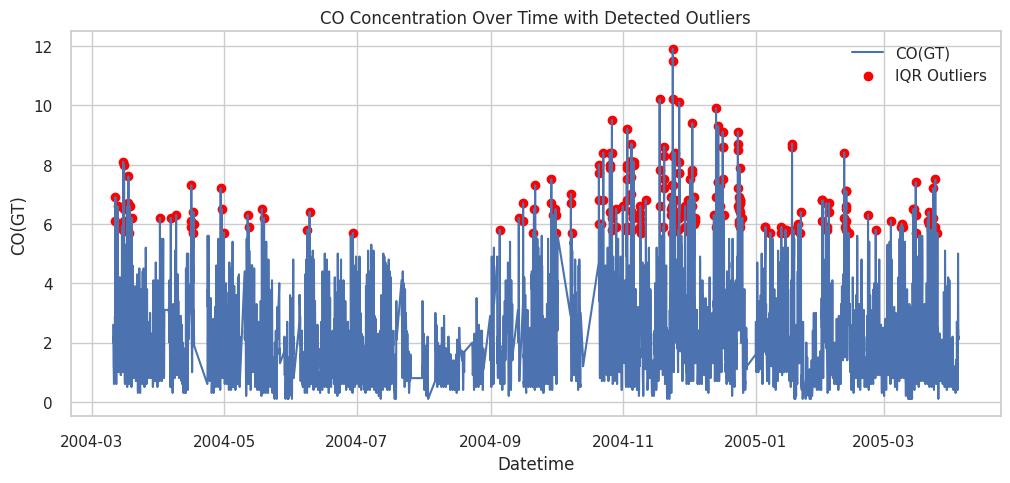

In [ ]:
# 14. Outlier Visualization

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Datetime', y='CO(GT)', label='CO(GT)')

plt.scatter(
    df_anomalies_iqr['Datetime'],
    df_anomalies_iqr['CO(GT)'],
    color='red',
    label='IQR Outliers'
)

plt.title('CO Concentration Over Time with Detected Outliers')
plt.xlabel('Datetime')
plt.ylabel('CO(GT)')
plt.legend()
plt.show()

In [ ]:
# 15. Statistical Analysis 1: Pearson Correlation Test
# RQ1: Is temperature significantly related to CO concentration?

corr_stat, corr_p = stats.pearsonr(df['T'], df['CO(GT)'])

print("=== PEARSON CORRELATION TEST ===")
print(f"Correlation coefficient: {corr_stat:.4f}")
print(f"p-value: {corr_p:.4f}")

if corr_p < 0.05:
    print("p < 0.05 → There is a statistically significant relationship between temperature and CO concentration.")
else:
    print("p > 0.05 → There is no statistically significant relationship between temperature and CO concentration.")

=== PEARSON CORRELATION TEST ===
Correlation coefficient: 0.0189
p-value: 0.0675
p > 0.05 → There is no statistically significant relationship between temperature and CO concentration.


In [ ]:
# 16. Statistical Analysis 2: Independent Sample t-test
# RQ2: Is CO concentration significantly different between daytime and nighttime?

day_co = df[df['DayNight'] == 'Daytime']['CO(GT)']
night_co = df[df['DayNight'] == 'Nighttime']['CO(GT)']

# Levene test for equal variance
levene_ttest = stats.levene(day_co, night_co)

print("=== LEVENE TEST FOR T-TEST ===")
print(f"Levene statistic: {levene_ttest.statistic:.4f}")
print(f"p-value: {levene_ttest.pvalue:.4f}")

# If Levene p < 0.05, use Welch's t-test
equal_variance = True if levene_ttest.pvalue > 0.05 else False

ttest_result = stats.ttest_ind(day_co, night_co, equal_var=equal_variance)

print("\n=== INDEPENDENT SAMPLE T-TEST ===")
print(f"t-statistic: {ttest_result.statistic:.4f}")
print(f"p-value: {ttest_result.pvalue:.4f}")

if ttest_result.pvalue < 0.05:
    print("p < 0.05 → CO concentration is significantly different between daytime and nighttime.")
else:
    print("p > 0.05 → CO concentration is not significantly different between daytime and nighttime.")

=== LEVENE TEST FOR T-TEST ===
Levene statistic: 6.6553
p-value: 0.0099

=== INDEPENDENT SAMPLE T-TEST ===
t-statistic: 20.0478
p-value: 0.0000
p < 0.05 → CO concentration is significantly different between daytime and nighttime.


In [ ]:
# 17. Statistical Analysis 3: One-Way ANOVA
# RQ3: Does CO concentration differ significantly across months?

model_1way = ols('Q("CO(GT)") ~ C(Month)', data=df).fit()
anova_1way = sm.stats.anova_lm(model_1way, typ=2)

print("=== ONE-WAY ANOVA: CO BY MONTH ===")
display(anova_1way)

p_anova = anova_1way['PR(>F)'].iloc[0]

if p_anova < 0.05:
    print("p < 0.05 → Month has a significant effect on CO concentration.")
else:
    print("p > 0.05 → Month does not have a significant effect on CO concentration.")

=== ONE-WAY ANOVA: CO BY MONTH ===


,sum_sq,df,F,PR(>F)
C(Month),1713.458531,11.0,83.346796,1.466110e-180
Residual,17465.109404,9345.0,NaN,NaN


p < 0.05 → Month has a significant effect on CO concentration.


In [ ]:
# 18. Tukey Post-hoc Test
# Use when One-Way ANOVA is significant

tukey_month = pairwise_tukeyhsd(
    endog=df['CO(GT)'],
    groups=df['Month'],
    alpha=0.05
)

print("=== TUKEY HSD TEST: MONTH DIFFERENCES ===")
print(tukey_month)

=== TUKEY HSD TEST: MONTH DIFFERENCES ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   0.0968 0.9752  -0.141  0.3347  False
     1      3   0.1189 0.7724 -0.0879  0.3257  False
     1      4   0.0522 0.9998 -0.1749  0.2793  False
     1      5  -0.0618 0.9994 -0.2935  0.1699  False
     1      6  -0.1191 0.8831 -0.3528  0.1145  False
     1      7  -0.2739 0.0063 -0.5055 -0.0422   True
     1      8  -0.6456    0.0 -0.8773 -0.4139   True
     1      9   0.2629 0.0126  0.0292  0.4965   True
     1     10   1.0401    0.0  0.8084  1.2718   True
     1     11   0.7527    0.0  0.5191  0.9863   True
     1     12   0.5772    0.0  0.3455  0.8089   True
     2      3    0.022    1.0 -0.1916  0.2357  False
     2      4  -0.0446    1.0  -0.278  0.1887  False
     2      5  -0.1587 0.5637 -0.3965  0.0792  False
     2      6   -0.216 0.1253 -0.4557  0.0237  False
    

In [ ]:
# 19. Statistical Analysis 4: Two-Way ANOVA
# RQ4: Do Month and Day/Night affect CO concentration?

model_2way = ols('Q("CO(GT)") ~ C(Month) * C(DayNight)', data=df).fit()
anova_2way = sm.stats.anova_lm(model_2way, typ=2)

print("=== TWO-WAY ANOVA: MONTH AND DAY/NIGHT EFFECT ===")
display(anova_2way)

print("\nInterpretation guide:")
print("C(Month): Main effect of month")
print("C(DayNight): Main effect of daytime/nighttime")
print("C(Month):C(DayNight): Interaction effect")

=== TWO-WAY ANOVA: MONTH AND DAY/NIGHT EFFECT ===


,sum_sq,df,F,PR(>F)
C(Month),1713.449476,11.0,87.629712,9.374137e-190
C(DayNight),790.001150,1.0,444.427054,2.034097e-96
C(Month):C(DayNight),85.027459,11.0,4.348498,1.592113e-06
Residual,16590.080794,9333.0,NaN,NaN



Interpretation guide:
C(Month): Main effect of month
C(DayNight): Main effect of daytime/nighttime
C(Month):C(DayNight): Interaction effect


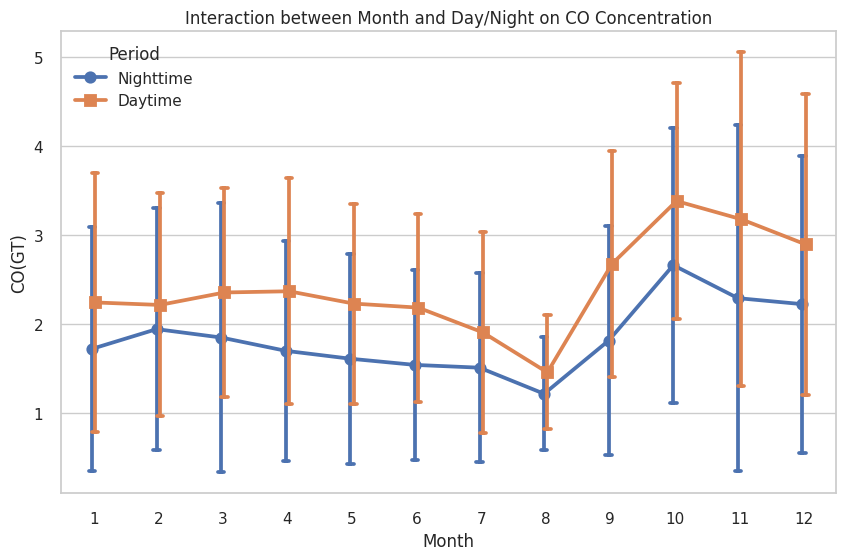

In [ ]:
# 20. Interaction Plot

plt.figure(figsize=(10, 6))

sns.pointplot(
    data=df,
    x='Month',
    y='CO(GT)',
    hue='DayNight',
    errorbar='sd',
    dodge=True,
    markers=['o', 's'],
    capsize=.1
)

plt.title('Interaction between Month and Day/Night on CO Concentration')
plt.xlabel('Month')
plt.ylabel('CO(GT)')
plt.legend(title='Period')
plt.show()

In [ ]:
# 21. ANOVA Assumption Test: Shapiro-Wilk Normality Test

residuals = model_2way.resid

# Shapiro-Wilk can be too sensitive for large datasets
# Use a sample of 5000 if dataset is large
if len(residuals) > 5000:
    residuals_sample = residuals.sample(5000, random_state=42)
else:
    residuals_sample = residuals

shapiro_test = stats.shapiro(residuals_sample)

print("=== SHAPIRO-WILK TEST ===")
print(f"Shapiro-Wilk statistic: {shapiro_test.statistic:.4f}")
print(f"p-value: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue > 0.05:
    print("p > 0.05 → Residuals are approximately normally distributed.")
else:
    print("p < 0.05 → Residuals are not normally distributed.")

=== SHAPIRO-WILK TEST ===
Shapiro-Wilk statistic: 0.9197
p-value: 0.0000
p < 0.05 → Residuals are not normally distributed.


In [ ]:
# 22. ANOVA Assumption Test: Levene's Test

month_groups = [
    group['CO(GT)'].values
    for name, group in df.groupby('Month')
]

levene_anova = stats.levene(*month_groups)

print("=== LEVENE TEST ACROSS MONTHS ===")
print(f"Levene statistic: {levene_anova.statistic:.4f}")
print(f"p-value: {levene_anova.pvalue:.4f}")

if levene_anova.pvalue > 0.05:
    print("p > 0.05 → Equal variance assumption holds.")
else:
    print("p < 0.05 → Equal variance assumption is violated.")

=== LEVENE TEST ACROSS MONTHS ===
Levene statistic: 47.8045
p-value: 0.0000
p < 0.05 → Equal variance assumption is violated.


In [ ]:
# 23. Non-parametric Alternative: Kruskal-Wallis Test
# Since the Shapiro-Wilk and Levene tests show that ANOVA assumptions are violated,
# Kruskal-Wallis is used as a non-parametric alternative.
# Use if ANOVA assumptions are violated

kruskal_result = stats.kruskal(*month_groups)

print("=== KRUSKAL-WALLIS TEST ===")
print(f"Kruskal statistic: {kruskal_result.statistic:.4f}")
print(f"p-value: {kruskal_result.pvalue:.4f}")

if kruskal_result.pvalue < 0.05:
    print("p < 0.05 → There is a significant difference in CO concentration across months.")
else:
    print("p > 0.05 → There is no significant difference in CO concentration across months.")

=== KRUSKAL-WALLIS TEST ===
Kruskal statistic: 749.2130
p-value: 0.0000
p < 0.05 → There is a significant difference in CO concentration across months.


In [ ]:
# 24. Final Summary Table

summary = {
    "Total Records": len(df),
    "Total Variables": len(df.columns),
    "Missing Values After Cleaning": df.isnull().sum().sum(),
    "Mean CO(GT)": round(df['CO(GT)'].mean(), 3),
    "Mean NO2(GT)": round(df['NO2(GT)'].mean(), 3),
    "Mean Temperature": round(df['T'].mean(), 3),
    "Mean Relative Humidity": round(df['RH'].mean(), 3),
    "CO-T Correlation": round(corr_stat, 3),
    "Z-score CO Outliers": len(df_anomalies_z),
    "IQR CO Outliers": len(df_anomalies_iqr),
    "T-test p-value": round(ttest_result.pvalue, 4),
    "One-Way ANOVA p-value": round(p_anova, 4),
    "Kruskal-Wallis p-value": round(kruskal_result.pvalue, 4)
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

print("Final Summary Table:")
display(summary_df)

Final Summary Table:


,Metric,Value
0,Total Records,9357.000
1,Total Variables,15.000
2,Missing Values After Cleaning,0.000
3,Mean CO(GT),2.131
4,Mean NO2(GT),109.632
5,Mean Temperature,18.233
6,Mean Relative Humidity,49.191
7,CO-T Correlation,0.019
8,Z-score CO Outliers,117.000
9,IQR CO Outliers,224.000


In [ ]:
print("=== FINAL INTERPRETATION ===")

print("This analysis explored urban air quality patterns using the AirQualityUCI dataset under the Smart City theme.")
print("After replacing invalid -200 sensor readings with missing values, interpolation and median filling were used to handle missing data.")

print("\nEDA Findings:")
print("- CO(GT) shows several high concentration peaks, indicating possible abnormal pollution events.")
print("- The correlation heatmap shows strong positive relationships among CO(GT), C6H6(GT), NOx(GT), and NO2(GT).")
print("- Temperature has a very weak relationship with CO(GT), which is supported by both the heatmap and Pearson correlation test.")
print("- Monthly CO concentration changes across the year, with higher average values observed around the later months.")

print("\nStatistical Findings:")
print("- Pearson correlation shows no statistically significant relationship between temperature and CO(GT).")
print("- The independent sample t-test shows that CO(GT) concentration differs significantly between daytime and nighttime.")
print("- One-way ANOVA shows that CO(GT) concentration differs significantly across months.")
print("- Two-way ANOVA shows that Month and Day/Night can be used to examine main and interaction effects on CO(GT).")
print("- Shapiro-Wilk and Levene tests show that ANOVA assumptions are violated.")
print("- Therefore, Kruskal-Wallis test was also used as a non-parametric alternative, and it confirmed significant monthly differences in CO(GT).")

print("\nConclusion:")
print("Overall, the findings suggest that CO concentration varies by time period and month, while temperature alone does not show a significant linear relationship with CO. These insights can support smart city environmental monitoring and air pollution management.")

=== FINAL INTERPRETATION ===
This analysis explored urban air quality patterns using the AirQualityUCI dataset under the Smart City theme.
After replacing invalid -200 sensor readings with missing values, interpolation and median filling were used to handle missing data.

EDA Findings:
- CO(GT) shows several high concentration peaks, indicating possible abnormal pollution events.
- The correlation heatmap shows strong positive relationships among CO(GT), C6H6(GT), NOx(GT), and NO2(GT).
- Temperature has a very weak relationship with CO(GT), which is supported by both the heatmap and Pearson correlation test.
- Monthly CO concentration changes across the year, with higher average values observed around the later months.

Statistical Findings:
- Pearson correlation shows no statistically significant relationship between temperature and CO(GT).
- The independent sample t-test shows that CO(GT) concentration differs significantly between daytime and nighttime.
- One-way ANOVA shows that CO